# **REGRESION LOGISTICA CON PYTORCH**

# **Dataset Dry Bean(HABA SECA)**

El presente experimento utiliza el Dry Bean Dataset provisto por el repositorio de Machine Learning de la UCI, el cual consta de un volumen total de 13,611 registros. Cada registro representa una captura automatizada de visión por computadora sobre granos de legumbres, extrayendo un espacio de características de 16 variables morfológicas numéricas continuas (tales como Área, Perímetro, Longitud del Eje Mayor, Redondez, Solidez y Coeficientes de Asimetría).

El vector de respuestas del sistema está compuesto dinámicamente por 7 clases o variedades biológicas únicas de frijoles, las cuales han sido indexadas numéricamente de la siguiente manera:

0: SEKER

1: BARBUNYA

2: BOMBAY

3: CALI

4: HOROZ

5: SIRA

6: DERMASON

El objetivo principal es diseñar, entrenar y evaluar un modelo de Regresión Logística Multiclase basado en el enfoque One-vs-All (Uno contra todos), con el fin de clasificar y predecir de forma automatizada la variedad a la que pertenece una semilla a partir de sus dimensiones físicas.

url:https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

**IMPORTAMOS LAS LIBRERIAS**

In [1]:

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.metrics import accuracy_score

# Activamos los gráficos en línea para el cuaderno
%matplotlib inline


**CARGAMOS EL DATA SET**

In [5]:
# ==============================================================================

ruta_dataset = "C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/Dry_Bean_Dataset.xlsx"
data = pd.read_excel(ruta_dataset)

# Mostramos las dimensiones del dataset
print(f'Dimensiones del dataset: {data.shape}')
print("\nCantidad de registros por clase original:")
print(data['Class'].value_counts())
data.head()

 

Dimensiones del dataset: (13611, 17)

Cantidad de registros por clase original:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


**Gráfica de distribución de las clases de frijoles**

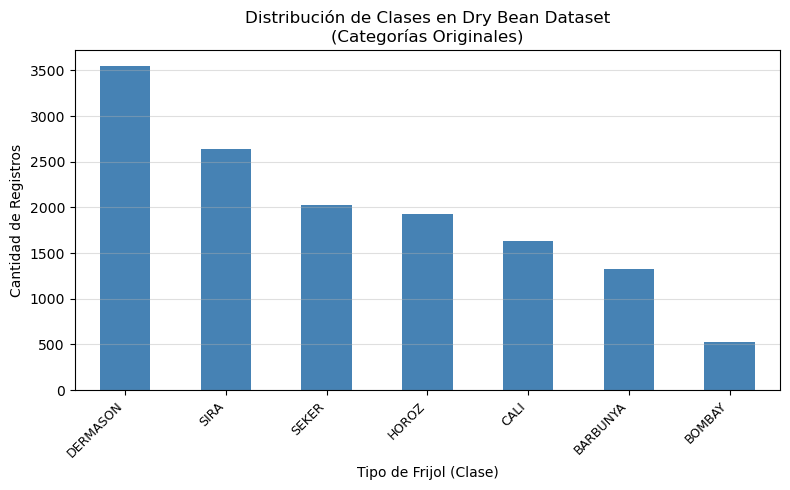

In [3]:
conteo_clases = data['Class'].value_counts()

pyplot.figure(figsize=(8, 5))
conteo_clases.plot(kind='bar', color='steelblue', ax=pyplot.gca())
pyplot.title('Distribución de Clases en Dry Bean Dataset\n(Categorías Originales)')
pyplot.xlabel('Tipo de Frijol (Clase)')
pyplot.ylabel('Cantidad de Registros')
pyplot.xticks(rotation=45, ha='right', fontsize=9)
pyplot.grid(axis='y', alpha=0.4)

pyplot.tight_layout()
pyplot.show()

In [6]:


# Crear un diccionario para mapear los nombres de las clases de texto a números (0 a 6)
clases_mapeo = {
    'SEKER': 0,
    'BARBUNYA': 1,
    'BOMBAY': 2,
    'CALI': 3,
    'DERMASON': 4,
    'HOROZ': 5,
    'SIRA': 6
}

# Convertimos la columna 'Class' a mayúsculas por seguridad y aplicamos el mapeo
data['Class'] = data['Class'].str.upper()
data['label_num'] = data['Class'].map(clases_mapeo)

# Definimos la lista de características (FEATURES) basadas en las columnas del Dry Bean Dataset
FEATURES = [
    'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
    'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter',
    'Extent', 'Solidity', 'roundness', 'Compactness',
    'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4'
]

TARGET = 'label_num'

# Verificamos y rellenamos valores nulos con la mediana (tal cual tu estructura base)
for col in FEATURES:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Extraemos las matrices X (características) e y (etiquetas) en formato float32
X = data[FEATURES].values.astype(np.float32)
y = data[TARGET].values.astype(np.float32)
m = y.size

print(f'Matriz X (Features) shape : {X.shape}')
print(f'Vector y (Target) shape   : {y.shape}')
print(f'Cantidad total de muestras (m): {m}')

Matriz X (Features) shape : (13611, 16)
Vector y (Target) shape   : (13611,)
Cantidad total de muestras (m): 13611


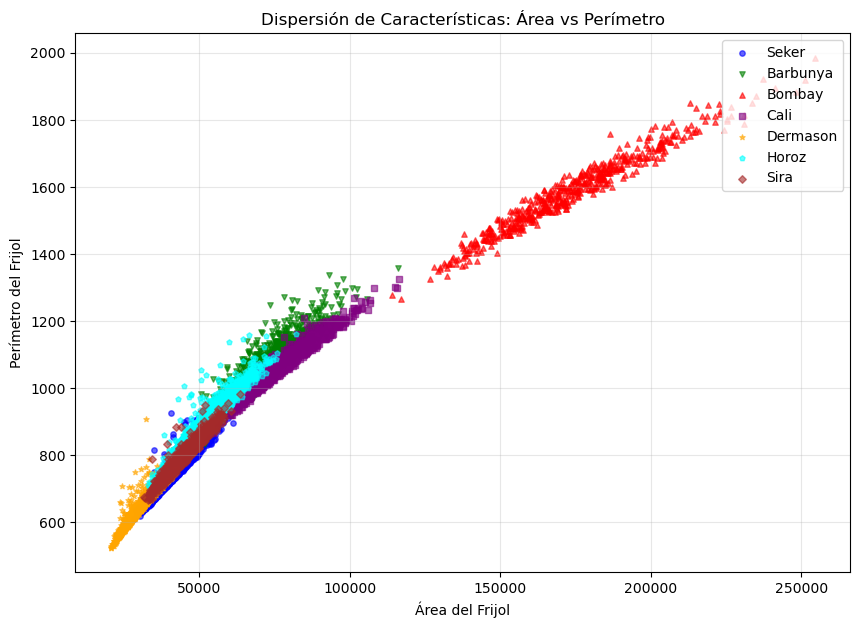

In [ ]:

def plotData(X, y):
    pyplot.figure(figsize=(10, 7))
    
    # Nombres de las clases en orden correspondiente al mapeo (0 al 6)
    nombres_frijoles = ['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermason', 'Horoz', 'Sira']
    # Colores y marcadores distintos para identificar cada tipo de frijol
    colores = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'brown']
    marcadores = ['o', 'v', '^', 's', '*', 'p', 'D']
    
    # Graficamos cada clase una por una
    for i in range(7):
        indices_clase = (y == i)
        pyplot.scatter(X[indices_clase, 0], X[indices_clase, 1], 
                       color=colores[i], marker=marcadores[i], 
                       label=nombres_frijoles[i], alpha=0.6, s=15)

# Llamamos a la función usando las dos primeras columnas (Area y Perimeter)
plotData(X, y)
pyplot.xlabel('Área del Frijol')
pyplot.ylabel('Perímetro del Frijol')
pyplot.title('Dispersión de Características: Área vs Perímetro')
pyplot.legend(loc='upper right')
pyplot.grid(True, alpha=0.3)
pyplot.show()

**NORMALIZACIÓN Y SPLIT 80/20**

In [ ]:

# Calculamos la media y desviación estándar para cada una de las 16 características
mu    = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

# Evitamos la división por cero si alguna característica tuviera desviación cero
sigma[sigma == 0] = 1

# Escalamos los datos (Normalización Z-score)
X = ((X - mu) / sigma).astype(np.float32)

# Configuración de la semilla aleatoria para que siempre dé el mismo resultado
np.random.seed(42)
indices = np.random.permutation(m)
split   = int(0.8 * m)

# División de los conjuntos en matrices de NumPy
X_train = X[indices[:split]]
y_train = y[indices[:split]]
X_test  = X[indices[split:]]
y_test  = y[indices[split:]]

print(f'Registros para Entrenamiento : {len(y_train):,}')
print(f'Registros para Validación    : {len(y_test):,}')

Registros para Entrenamiento : 10,888
Registros para Validación    : 2,723


In [10]:
# Convertimos los arrays de numpy a tensores de PyTorch
X_t = torch.from_numpy(X_train).float()

# NOTA DE ADAPTACIÓN IMPORTANTE:
# Para clasificación multiclase en PyTorch usando la pérdida "CrossEntropyLoss",
# las etiquetas 'Y' de entrenamiento deben ser tensores de tipo entero largo (LongTensor)
# y deben mantener una sola dimensión (forma de vector plano), no una columna (.view(-1,1)).
Y_t = torch.from_numpy(y_train).long()

print(f'\nForma final de los tensores de PyTorch:')
print(f'X_t shape: {X_t.shape}  -> (Muestras, Características)')
print(f'Y_t shape: {Y_t.shape}    -> (Muestras,)')


Forma final de los tensores de PyTorch:
X_t shape: torch.Size([10888, 16])  -> (Muestras, Características)
Y_t shape: torch.Size([10888])    -> (Muestras,)


**DEFINIR EL MODELO**

Se crea una clase que hereda de torch.nn.Module. En __init__ se definen las capas y en forward la lógica de cálculo.

In [ ]:

# Creamos la clase que hereda de torch.nn.Module
class ModeloRegresionLogisticaMulticlase(nn.Module):

    # Constructor
    def __init__(self, D_in, D_out):
        # Llamamos al constructor de la clase madre
        super(ModeloRegresionLogisticaMulticlase, self).__init__()

        # Definimos la capa lineal (mapea de 16 características a 7 salidas)
        self.fc = nn.Linear(D_in, D_out)

    # Lógica para calcular las salidas de la red (logits)
    def forward(self, x):
        # IMPORTANTE: No aplicamos sigmoid aquí; devolvemos el resultado de la capa lineal directo.
        # PyTorch maneja el Softmax internamente con la función de pérdida.
        x = self.fc(x)
        return x

# Definimos las dimensiones de nuestra red
D_in  = X_t.shape[1]  # Número de features del Dry Bean Dataset (16)
D_out = 7             # Número de clases de frijoles (0 al 6)

# Instanciamos el modelo
model = ModeloRegresionLogisticaMulticlase(D_in, D_out)
print("Estructura de nuestro modelo:")
print(model)

# Verificar que el modelo recibe los datos y entrega la forma correcta
# Pasamos una prueba con 5 muestras aleatorias
x_prueba = torch.randn(5, D_in)
outputs  = model(x_prueba)
print(f"\nForma de la salida de prueba: {outputs.shape} -> (5 muestras, 7 puntuaciones por clase)")

Estructura de nuestro modelo:
ModeloRegresionLogisticaMulticlase(
  (fc): Linear(in_features=16, out_features=7, bias=True)
)

Forma de la salida de prueba: torch.Size([5, 7]) -> (5 muestras, 7 puntuaciones por clase)


**FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR**

In [ ]:

# Cambiamos BCELoss por CrossEntropyLoss para soportar las 7 clases
criterion = nn.CrossEntropyLoss()

# El optimizador se mantiene como Descenso de Gradiente Estocástico (SGD)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

**ENTRENAMIENTO**

In [ ]:

epochs   = 500
log_each = 100
l = []

# Ponemos el modelo en modo de entrenamiento
model.train()

for e in range(1, epochs + 1):

    # 1. Se calculan las predicciones (logits) con los parámetros actuales
    y_pred = model(X_t)

    # 2. Se calcula el error entre la predicción y el valor real (Y_t)
    loss = criterion(y_pred, Y_t)
    l.append(loss.item())

    # 3. Se limpian los gradientes del paso anterior para no acumularlos
    optimizer.zero_grad()

    # 4. Se calculan automáticamente todos los gradientes mediante Backpropagation
    loss.backward()

    # 5. Se actualizan los pesos y sesgos del modelo con los gradientes calculados
    optimizer.step()

    # Imprimimos el avance cada 100 épocas
    if not e % log_each:
        print(f'Epoch {e}/{epochs} Loss {np.mean(l):.5f}')

Epoch 100/500 Loss 0.85634
Epoch 200/500 Loss 0.67124
Epoch 300/500 Loss 0.57907
Epoch 400/500 Loss 0.52158
Epoch 500/500 Loss 0.48160


**GRÁFICA DE CONVERGENCIA DEL COSTO**

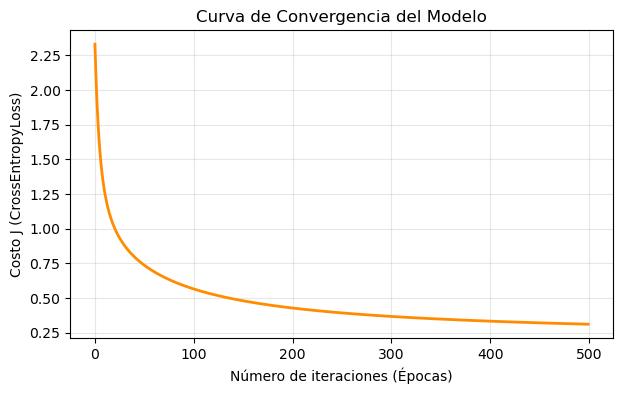

In [ ]:

pyplot.figure(figsize=(7, 4))
pyplot.plot(np.arange(len(l)), l, lw=2, color='darkorange')
pyplot.xlabel('Número de iteraciones (Épocas)')
pyplot.ylabel('Costo J (CrossEntropyLoss)')
pyplot.title('Curva de Convergencia del Modelo')
pyplot.grid(True, alpha=0.3)
pyplot.show()

**EVALUACIÓN DEL MODELO**

In [ ]:

def evaluate(x_matriz):
    # Ponemos el modelo en modo de evaluación (apaga capas de entrenamiento si las hubiera)
    model.eval()
    
    with torch.no_grad():
        # Convertimos la matriz de entrada a tensor de PyTorch si viene de numpy
        if isinstance(x_matriz, np.ndarray):
            x_tensor = torch.from_numpy(x_matriz).float()
        else:
            x_tensor = x_matriz
            
        # Obtenemos los logits (las 7 puntuaciones de salida)
        logits = model(x_tensor)
        
        # Para multiclase, la predicción es el índice del valor máximo en las columnas (dim=1)
        predicciones = torch.argmax(logits, dim=1).numpy()
        
        # Aplicamos Softmax internamente solo para obtener las probabilidades reales de cada clase (0 a 1)
        probs = torch.softmax(logits, dim=1).numpy()
        
        return predicciones, probs

# Evaluamos en el conjunto de entrenamiento
pred_train, _ = evaluate(X_t)
prec_train = accuracy_score(y_train, pred_train) * 100
print('Precisión entrenamiento: {:.2f}%'.format(prec_train))

# Evaluamos en el conjunto de validación (test)
pred_test, prob_test = evaluate(X_test)
prec_test = accuracy_score(y_test, pred_test) * 100
print('Precisión validación   : {:.2f}%'.format(prec_test))

Precisión entrenamiento: 91.62%
Precisión validación   : 91.85%


**PREDICCIONES FINALES**

In [ ]:

# Creamos un diccionario inverso para convertir los números de vuelta a los nombres de los frijoles
clases_inverso = {v: k for k, v in clases_mapeo.items()}

print('Precisión del conjunto de validación: {:.2f}%'.format(prec_test))
print()
print('Predicciones finales en el conjunto de prueba (Primeros 20 registros):')
print('-' * 85)

for i in range(20):
    real_num = int(y_test[i])
    pred_num = int(pred_test[i])
    
    # Extraemos la probabilidad más alta (la de la clase que el modelo eligió)
    prob_ganadora = prob_test[i][pred_num]
    
    # Convertimos los números a sus nombres legibles
    etiq_real = clases_inverso[real_num].ljust(12)
    etiq_pred = clases_inverso[pred_num].ljust(12)
    
    # Marcador de acierto o fallo
    correcto = '✓' if real_num == pred_num else '✗'
    
    print(f'Real: {etiq_real} | Predicción: {etiq_pred} | Prob: {prob_ganadora:.4f} | {correcto}')

Precisión del conjunto de validación: 91.85%

Predicciones finales en el conjunto de prueba (Primeros 20 registros):
-------------------------------------------------------------------------------------
Real: DERMASON     | Predicción: SIRA         | Prob: 0.4572 | ✗
Real: HOROZ        | Predicción: DERMASON     | Prob: 0.7440 | ✗
Real: CALI         | Predicción: CALI         | Prob: 0.8179 | ✓
Real: CALI         | Predicción: CALI         | Prob: 0.8028 | ✓
Real: SIRA         | Predicción: SIRA         | Prob: 0.6647 | ✓
Real: SEKER        | Predicción: SEKER        | Prob: 0.9672 | ✓
Real: DERMASON     | Predicción: DERMASON     | Prob: 0.8008 | ✓
Real: DERMASON     | Predicción: SIRA         | Prob: 0.6357 | ✗
Real: SEKER        | Predicción: SEKER        | Prob: 0.9880 | ✓
Real: SEKER        | Predicción: SEKER        | Prob: 0.9786 | ✓
Real: DERMASON     | Predicción: DERMASON     | Prob: 0.8081 | ✓
Real: SIRA         | Predicción: DERMASON     | Prob: 0.5480 | ✗
Real: SIRA       